## Radial Velocity Activity

In this activity, we will be looking at some plotted spectra and measuring their velocities. As usual, begin by running the first cell to import Matplotlib and NumPy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Now, on to the science! The data/ folder in your RM4 folder contains spectra of 3 stars (labeled 6004761, 1757844, 491422). Your task is to measure the radial velocities of these stars. 

The first step is to edit the function below to incorporate what you learned today about the Doppler shift. Modify this function so that it converts the template rest wavelength array to a Doppler shifted moving wavelength.

In [2]:
def shiftToMoving(restLambda, v):
    c = 299792.458 #Speed of light in km/s
    newLambda = restLambda * (1 + v/c)
    return newLambda

Make sure that your code makes sense: If you apply a positive velocity, should the shifted wavelength be longer or shorter than the original wavelength? Does your code reproduce your expectation? Test your code below with my favorite rest wavelength and a few velocities.

In [5]:
rest_h_alpha=6563.
#Fill in code here to test shiftToMoving with v=200 km/s and v=-200 km/s. Does your answer make sense?
v_pos = 200 # km/s
v_neg = -200 # km/s

shifted_pos = shiftToMoving(rest_h_alpha, v_pos)
shifted_neg = shiftToMoving(rest_h_alpha, v_neg)

print(f"Original H-alpha wavelength: {rest_h_alpha}")
print(f"Shifted for v = {v_pos} km/s: {shifted_pos} -> redshift")
print(f"Shifted for v = {v_neg} km/s: {shifted_neg} -> blueshift")


Original H-alpha wavelength: 6563.0
Shifted for v = 200 km/s: 6567.3783623135705 -> redshift
Shifted for v = -200 km/s: 6558.6216376864295 -> blueshift


Now on to our 3 stars for today's activity. The first step is to pick a science star and a template star and read in the files. Fill in the name of the star in "star_name" (e.g., 6004761, 1757844, or 491422) and pick a template to put in "temp_name" (e.g., MS, RGB, AGB).

In [6]:
star_name='491422'
temp_name='AGB'
scienceFile = '../data/' + star_name + '_spec.txt'
templateFile = '../data/' + temp_name+ '_tmpl.txt'

sciLambda, sciFlux = np.loadtxt(scienceFile, unpack = True)
tmpLambda, tmpFlux = np.loadtxt(templateFile, unpack = True)

This next line is the key line in the code--it shifts the template velocity to your suggested velocity for the star, and makes a plot showing the two. Put in an intial guess for the velocity of the star and see how it looks!

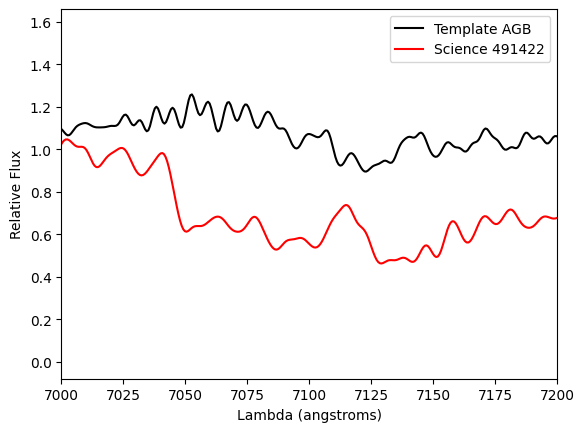

In [8]:
v_guess=120
#Shift template spectrum using the Doppler equation
new_tmpLambda = shiftToMoving(tmpLambda, v_guess)

#Plot science and template spectra on the same axes.
ax = plt.axes()
ax.plot(new_tmpLambda, tmpFlux, c = 'black', label = 'Template ' + temp_name)
ax.plot(sciLambda, sciFlux, c = 'red', label = 'Science ' + star_name)
ax.set_xlabel('Lambda (angstroms)')
ax.set_ylabel('Relative Flux')
ax.set_xlim(7000, 7200)
plt.legend()

Does the template look like a good match for this star? Try the other two templates to see which one looks the most like the science star. Do this by editing temp_name above, and then re-run the cell that reads in the files and the cell that shifts the wavelength and makes the plot.

After you're happy with your template, use the command ax.set_xlim(7000, 7200) to zoom in on the region between 7000 and 7200 angstroms. Play with "v_guess" until you're happy with how the two are lined up. Once you're happy with your velocity, write it down--and repeat with the next two science stars! 

Record your velocities here (double click on this cell to edit, then press Shift+Enter when you're done):

6004761: Template= AGB,Velocity = 2000

1757844: Template= AGB,Velocity = 1000

491422: Template= AGB,Velocity = 120 


## Radial Velocity Map of Andromeda

Now that you've successfully measured the velocities of a few stars, let's look at the velocities of all the stars we have in the Andromeda galaxy! First, we need to read in the data file containing our velocities:

In [9]:
#Read in data
ra, dec, xi, eta, f475w, f814w, v, verr = np.loadtxt('../data/keck_hst_data.txt', unpack = True)

#conversion factor: degrees to kiloparsecs (this is a distance)
deg2kpc = 13.67
xi *= deg2kpc
eta *= deg2kpc

Now we make the plot showing the positions of the stars and color coding the stars based on their velocities.

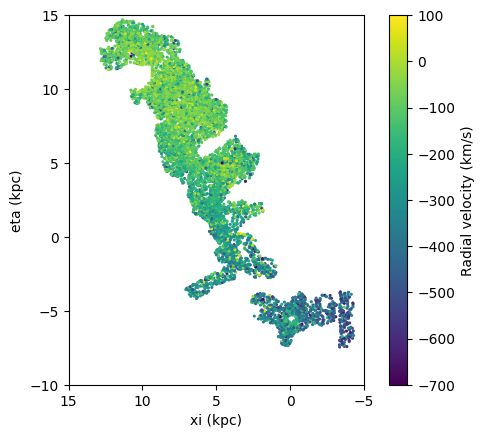

In [14]:
ax = plt.axes(aspect = 'equal')
ax.set_xlabel('xi (kpc)')
ax.set_ylabel('eta (kpc)')
ax.set_xlim(15, -5)
ax.set_ylim(-10, 15)
cc = ax.scatter(xi, eta, c = v, s = 5, edgecolors = 'none', vmin = -700, vmax = 100,
                cmap='viridis')   # viridis is the default for matplotlib versions > 2
plt.colorbar(cc, label = 'Radial velocity (km/s)')

Label parts of the plot as "blueshifted," "redshifted," or "neither," relative to M31's center. You can use the ax.text() command to edit the plot--for example,

ax.text(1, -.5, ‘I am at school late today.’)

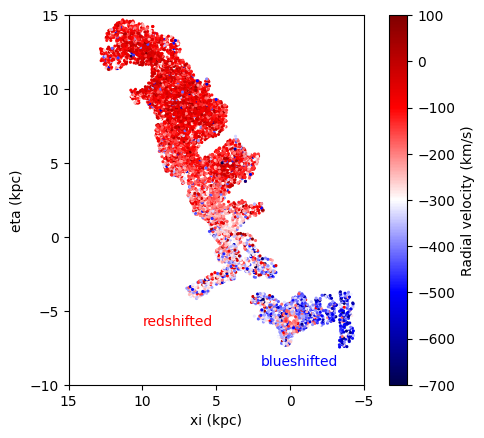

In [24]:
# Redo the map with a different colorbar that visually
# illustrates red and blue-shifted regions.  For a list
# of all of matplotlib's colormaps see here:
# https://matplotlib.org/users/colormaps.html
ax = plt.axes(aspect = 'equal')
ax.set_xlabel('xi (kpc)')
ax.set_ylabel('eta (kpc)')
ax.set_xlim(15, -5)
ax.set_ylim(-10, 15)
cc = ax.scatter(xi, eta, c = v, s = 5, edgecolors = 'none', vmin = -700, vmax = 100,
                cmap='seismic')

ax.text(2, -8.7, 'blueshifted', color = 'blue')
ax.text(10, -6, 'redshifted', color = 'red')

plt.colorbar(cc, label = 'Radial velocity (km/s)')

Based on your plot, what is the systemic velocity (average velocity) of Andromeda relative to us?

In [ ]:
#take the average (mean) of all the stars
systemic_velocity = np.mean(v)
print(f"Systemic Velocity of Andromeda relative to us: {systemic_velocity}")